# Source C — Key Findings: FRED Economic Velocity

This notebook shows the most important, already-verified results from
`analysis-output/source-c/source-c-findings.md`. It loads existing computed
artifacts (`source_c_stats.json`, saved figures, quadrant/similarity CSVs)
rather than re-running the full ingestion or analysis pipeline.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "analysis-output" else Path.cwd()
FIGURES_DIR = REPO_ROOT / "analysis-output" / "figures"

with open(REPO_ROOT / "analysis-output" / "source_c_stats.json") as f:
    stats = json.load(f)
stats

{'total_counties': 3144,
 'missing_gdp_count': 64,
 'missing_gdp_rate': 0.020356234096692113,
 'missing_gdp_is_independent_city_rate': 0.4375,
 'missing_by_state': {'Virginia': 51,
  'Connecticut': 9,
  'Alaska': 2,
  'Hawaii': 2},
 'quadrant_n_counties': 3080,
 'quadrant_counts': {'Growing but Loosening': 1966,
  'Decelerating & Loosening': 541,
  'Accelerating & Tightening': 465,
  'Slowing but Tightening': 108},
 'velocity_correlation': 0.009370531179030186,
 'corpus_mean_pairwise_km': 1430.8733910233852,
 'top_diverging_pair_economic_distance': 21.799371926417315}

## 1. Dataset

3,144 US counties/county-equivalents, each with annual unemployment-rate
and real-GDP series from FRED, reduced to a rolling 3-year first
derivative ("velocity") of each. Coverage: 3,080 counties (98.0%) have
both series, 63 (2.0%) have unemployment only, and 1 (Kalawao County, HI —
population ~90, the smallest US county) has neither.

In [2]:
source_c_df = pd.read_parquet(REPO_ROOT / "data" / "source_c_fred.parquet")
print(f"{len(source_c_df):,} counties")
source_c_df[["county_name", "fips_code", "unemployment_velocity", "gdp_velocity"]].head()

3,144 counties


,county_name,fips_code,unemployment_velocity,gdp_velocity
0,"Autauga County, Alabama",01001,0.066667,6598.333333
1,"Baldwin County, Alabama",01003,0.100000,503735.666667
2,"Barbour County, Alabama",01005,0.000000,-3104.333333
3,"Bibb County, Alabama",01007,0.100000,5115.666667
4,"Blount County, Alabama",01009,0.100000,47252.666667


## 2. Finding: GDP Coverage Gap Has Two Distinct Root Causes

64 counties (2.0%) are missing a GDP series. 51 of those are Virginia
independent cities (the same edge-case geography that needed a lookup
table for Source A's Wikipedia titles); 9 are *every single* Connecticut
geography in the crosswalk — not an independent-city issue, but a
consequence of Connecticut dissolving its traditional counties in 2022 in
favor of 9 new Planning Regions that BEA/FRED's GDP series hasn't
backfilled yet.

In [3]:
print("Missing GDP by state:", stats["missing_by_state"])
gdp_coverage = pd.read_csv(REPO_ROOT / "outputs" / "source_c_gdp_coverage.csv")
gdp_coverage.head(10)

Missing GDP by state: {'Virginia': 51, 'Connecticut': 9, 'Alaska': 2, 'Hawaii': 2}


,county_name,fips_code,state,is_independent_city
0,"Chugach Census Area, Alaska",2063,Alaska,False
1,"Copper River Census Area, Alaska",2066,Alaska,False
2,"Capitol Planning Region, Connecticut",9110,Connecticut,False
3,"Greater Bridgeport Planning Region, Connecticut",9120,Connecticut,False
4,Lower Connecticut River Valley Planning Region...,9130,Connecticut,False
5,"Naugatuck Valley Planning Region, Connecticut",9140,Connecticut,False
6,"Northeastern Connecticut Planning Region, Conn...",9150,Connecticut,False
7,"Northwest Hills Planning Region, Connecticut",9160,Connecticut,False
8,"South Central Connecticut Planning Region, Con...",9170,Connecticut,False
9,"Southeastern Connecticut Planning Region, Conn...",9180,Connecticut,False


## 3. Finding: Momentum Quadrants — One Quadrant Dominates

Classifying counties by sign of GDP velocity x sign of unemployment
velocity, nearly two-thirds (63.8%) fall into a single quadrant:
GDP still growing, but unemployment also rising. This reads as a shared
macro trend (labor market normalizing upward off 2022 lows, while GDP
keeps expanding almost everywhere) rather than the differentiated
"different markets, different quadrants" picture the proposal's
illustrative example describes.

Quadrant counts: {'Growing but Loosening': 1966, 'Decelerating & Loosening': 541, 'Accelerating & Tightening': 465, 'Slowing but Tightening': 108}


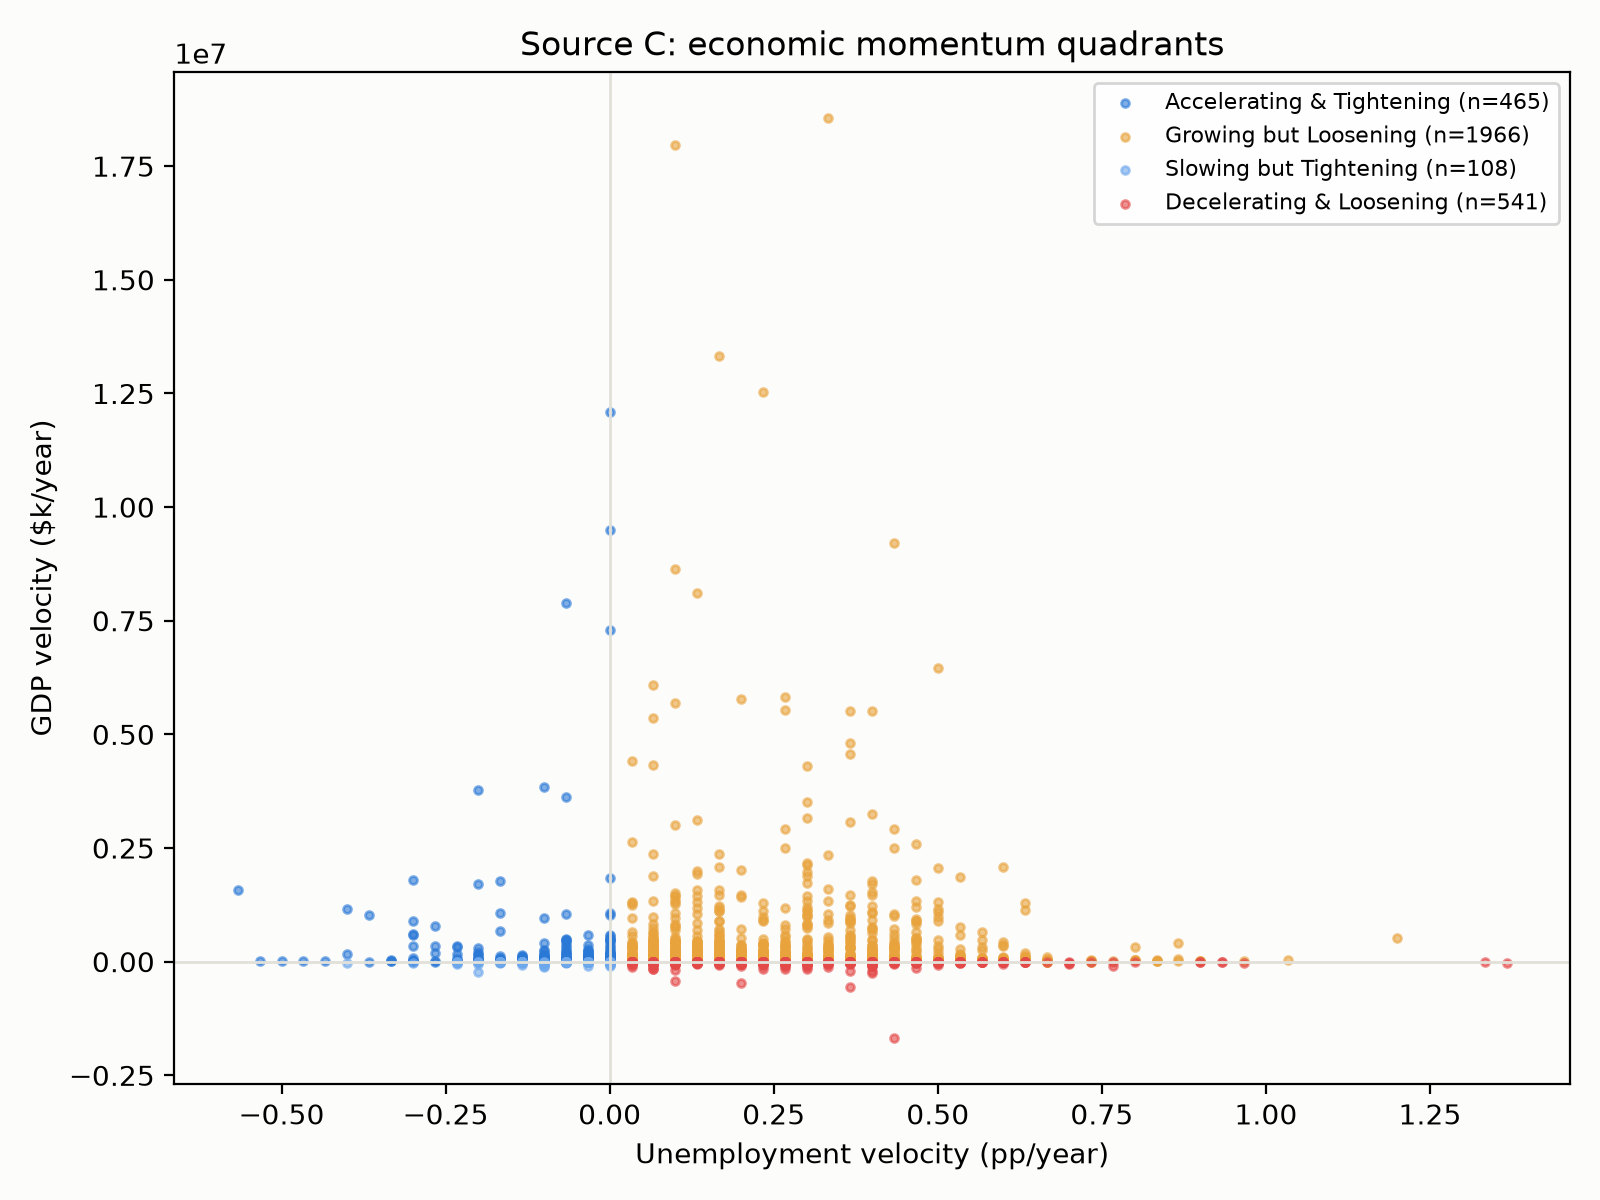

In [4]:
print("Quadrant counts:", stats["quadrant_counts"])
display(Image(filename=str(FIGURES_DIR / "source-c-figure-01-quadrants.png")))

## 4. Finding: Near-Zero Correlation Between the Two Velocity Axes

Pearson r = 0.0094 between unemployment velocity and GDP velocity across
the 3,080 fully-covered counties -- essentially no linear relationship,
which runs counter to a naive Okun's-law expectation. Consistent with
section 3: when most counties share the same quadrant (both rising), there's
little of the *opposing*-direction variation that would produce a
negative correlation.

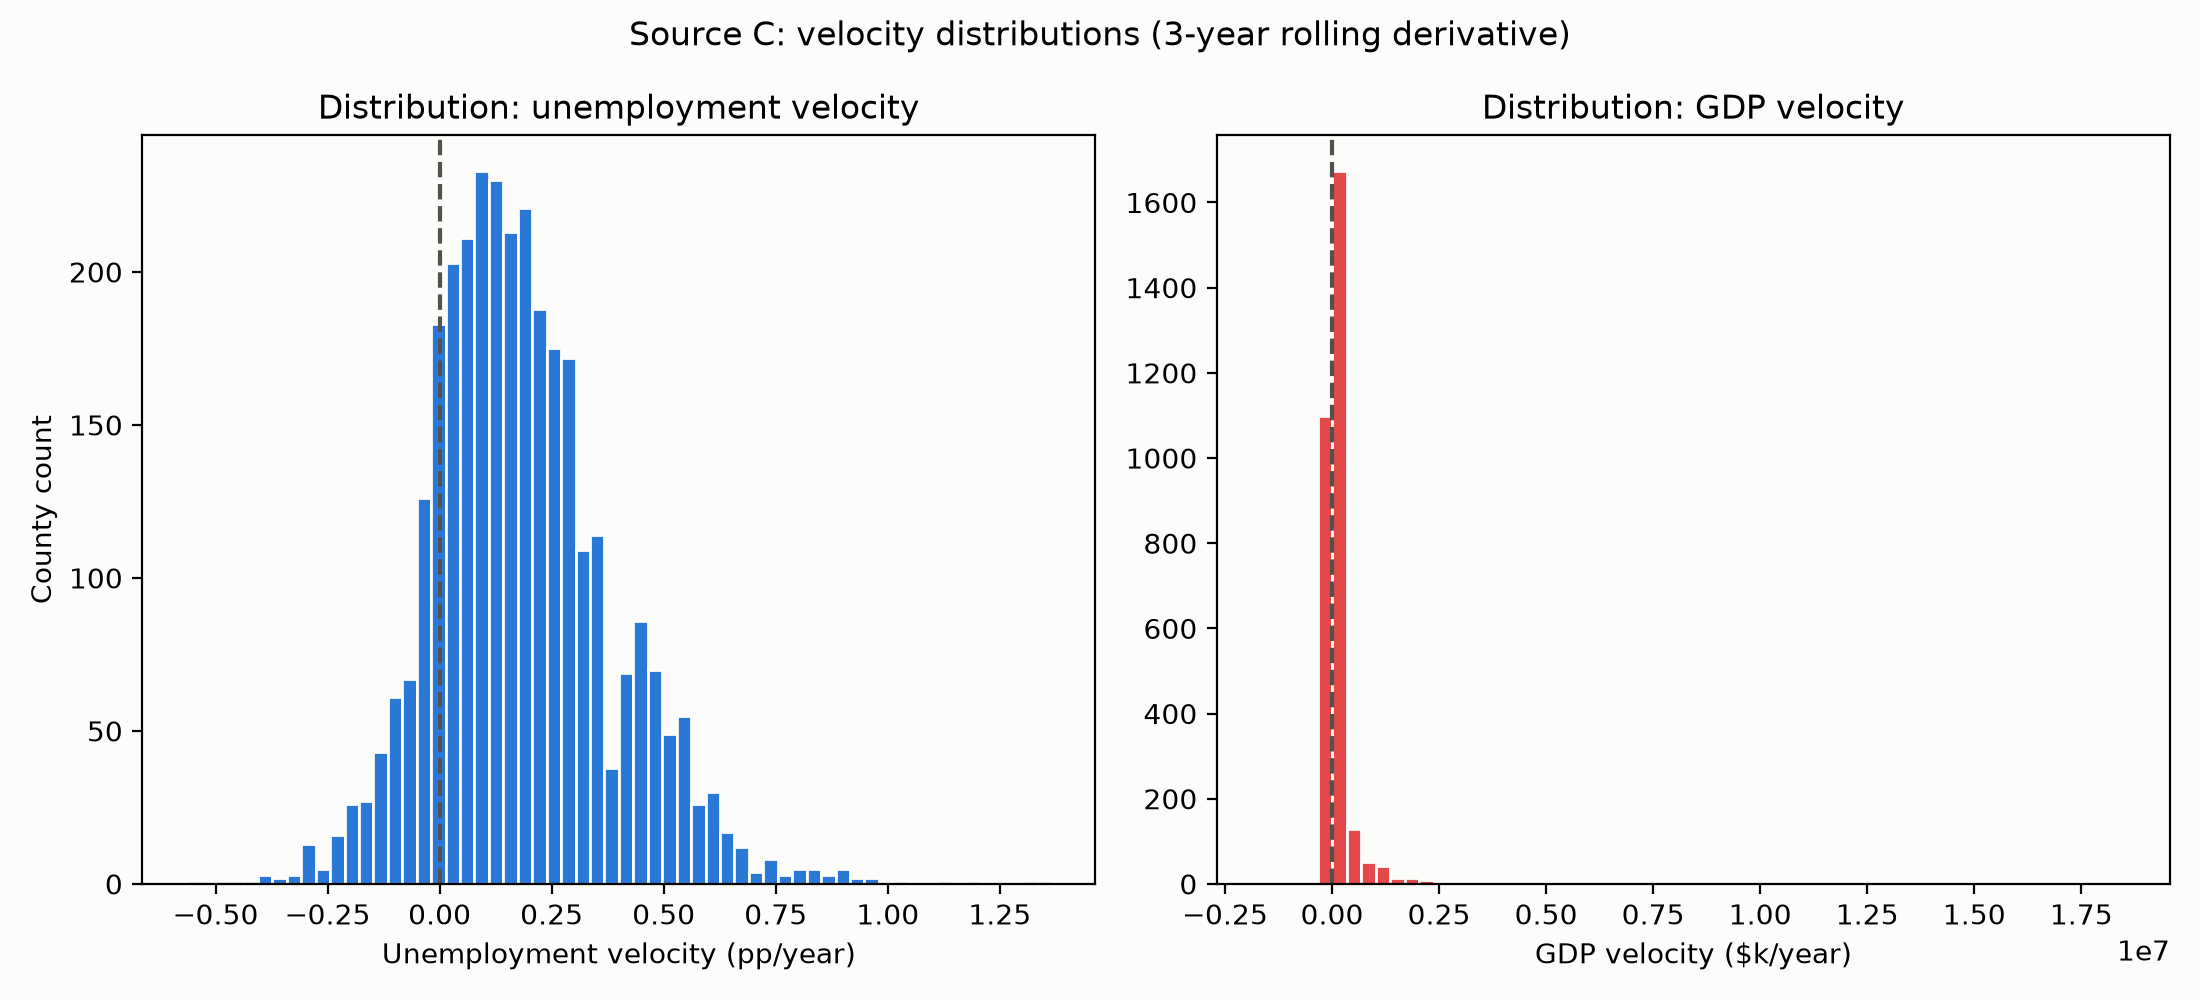

In [5]:
display(Image(filename=str(FIGURES_DIR / "source-c-figure-02-velocity-distributions.png")))

## 5. Finding: Geographic Proximity vs. Economic Divergence — a Single Outlier

Standardizing both velocity axes and ranking geographically-close county
pairs by economic distance, **King County, WA appears in every one of the
top-20 pairs**, paired with a wide variety of neighbors across four
states. This points to a methodological limitation (section 6), not a data
error: King County is simply the largest-magnitude outlier in the
dataset, so it dominates any distance-based ranking regardless of who
it's paired with.

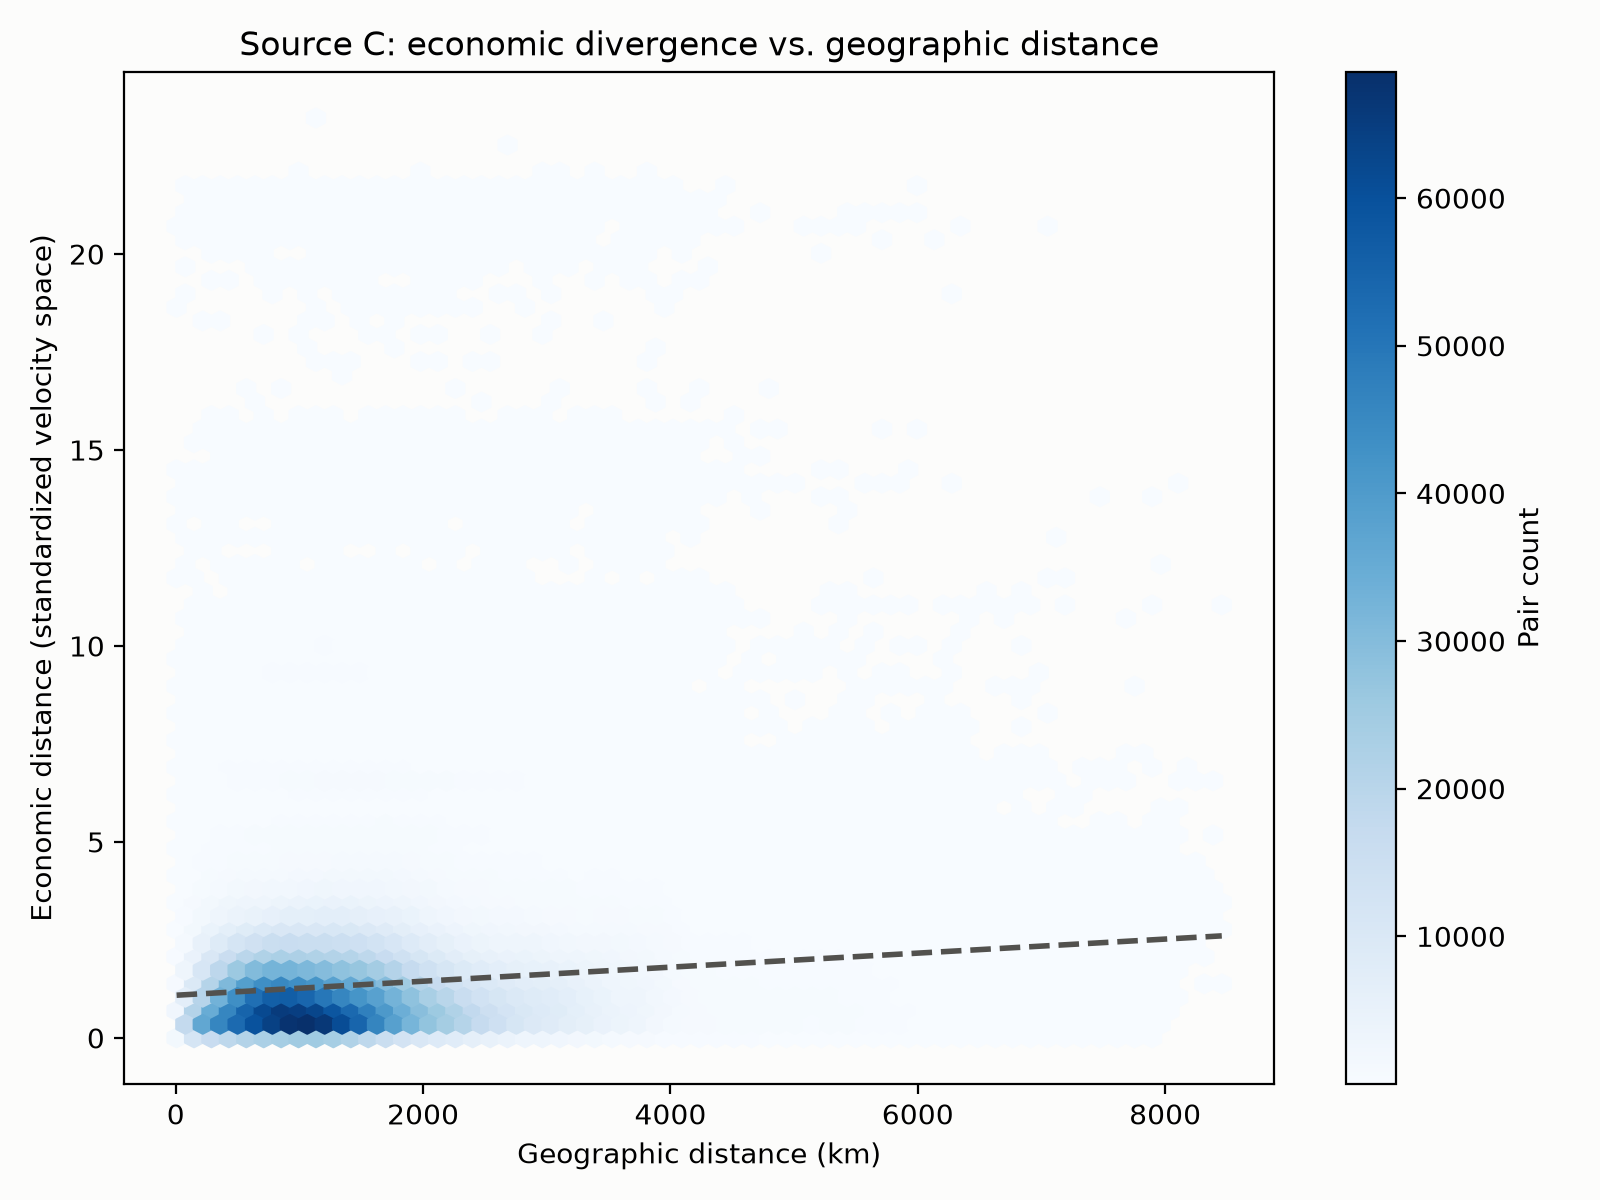

,county_a,county_b,economic_distance,distance_km
0,"Garfield County, Washington","King County, Washington",21.799372,346.761929
1,"King County, Washington","Yakima County, Washington",21.777629,141.795388
2,"King County, Washington","Whitman County, Washington",21.616317,331.166622
3,"Lewis County, Idaho","King County, Washington",21.602477,434.218944
4,"Humboldt County, Nevada","King County, Washington",21.600964,737.353402
5,"King County, Washington","Pacific County, Washington",21.600788,180.542879
6,"Camas County, Idaho","King County, Washington",21.595144,706.332728
7,"Ferry County, Washington","King County, Washington",21.575051,268.825718
8,"Asotin County, Washington","King County, Washington",21.572231,379.319462
9,"Mineral County, Montana","King County, Washington",21.559893,510.218077


In [6]:
display(Image(filename=str(FIGURES_DIR / "source-c-figure-03-proximity-vs-divergence.png")))
similarity_pairs = pd.read_csv(REPO_ROOT / "outputs" / "source_c_similarity_pairs.csv")
similarity_pairs.head(10)

## 6. Limitation: Absolute-Dollar GDP Velocity Measures Economy Size, Not Acceleration Rate

The five largest `gdp_velocity` values belong to King County WA, Harris
County TX, Maricopa County AZ, Los Angeles County CA, and New York County
NY — precisely the five largest county economies by `gdp_latest`. A large
economy produces a large absolute-dollar year-over-year change even at a
modest *percentage* growth rate, so this metric tracks economy size more
than "how fast is this county accelerating," which is what the proposal's
narrative describes. This matches what the pre-scoping spec's literal
formula produces — not a bug, but a real gap between the proposal's
framing and the metric as implemented. A relative velocity
(`gdp_velocity / gdp_latest`) is flagged as a natural follow-up rather
than substituted silently this round.

In [7]:
top_gdp = source_c_df.nlargest(5, "gdp_velocity")[["county_name", "gdp_velocity", "gdp_latest"]]
top_gdp

,county_name,gdp_velocity,gdp_latest
2971,"King County, Washington",1.855923e+07,409159636.0
2625,"Harris County, Texas",1.796569e+07,458701746.0
104,"Maricopa County, Arizona",1.332304e+07,329775922.0
205,"Los Angeles County, California",1.252098e+07,810842127.0
1860,"New York County, New York",1.208509e+07,813692135.0


## 7. Proposal Alignment Summary

See `analysis-output/source-c/source-c-findings.md` section 9 for the full assessment.
Short version: the quadrant mechanism works and does differentiate
counties (15.1% in the strongest quadrant vs. 3.5% in the weakest), but a
large share of that split reflects a shared macro trend rather than
purely idiosyncratic local momentum — and the GDP velocity metric
measures economy size more than acceleration rate. Both are documented
findings, not implementation defects.